# R14 Rank5 路径质量实验

## tl;dr

- 六个预注册路径质量变体均未通过一进一出门禁，保留 R14。
- 最接近的 4% 日波动率上限仅增加 0.037 个百分点总收益，却把跳过订单率提高 0.207 个百分点。
- 511 条 Rank5 库存均具备完整 20 日路径特征，基线逐单摘要精确复现；否决不是缺数或重放漂移造成的。
- 停止在这 22 笔已平仓 Rank5 样本上继续做历史阈值搜索。

## Context & Methods

决策问题是：新的、信号日可得的价格路径特征，能否让某一变体一对一替换当前 R14，而不增加第四个活跃策略角色。

### Key Assumptions

- 每个特征只使用信号日收盘及以前的最近 21 个有效收盘价，形成 20 个简单日收益率。
- 六个圆整阈值在读取特征分布和候选结果前冻结。
- 晋级必须同时守住可复现基线和旧 R14 展示合同的九项指标，并产生至少一项 10% 相对突破或减少一个亏损月。
- 历史回放不等同于未来收益证据。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
EXPERIMENT = ROOT / "docs/contracts/SHORTPICK_V3_R14_RANK5_PATH_QUALITY_EXPERIMENT_2026-07-15.json"
DESIGN = ROOT / "docs/contracts/SHORTPICK_V3_R14_RANK5_PATH_QUALITY_DESIGN_2026-07-15.json"
experiment = json.loads(EXPERIMENT.read_text(encoding="utf-8"))
design = json.loads(DESIGN.read_text(encoding="utf-8"))
experiment["decision"], design["status"]

('retain_r14_no_rank5_path_quality_candidate_cleared_gate',
 'frozen_before_candidate_outcome_evaluation')

## Data

输入是治理目录中固定的 R14 执行快照；本 notebook 读取机器可读实验产物，不重新选择阈值。

In [2]:
source = experiment["source_execution_snapshot"]
coverage = experiment["feature_contract_validation"]["coverage"]
assert source["exact_replay"] is True
assert coverage["rank5_complete_feature_rate"] == 1.0
assert experiment["accepted_research_candidate_ids"] == []
assert experiment["feature_contract_validation"]["outcome_fields_used_for_candidate_selection"] == []
{
    "snapshot": source["artifact_id"],
    "inventory_rows": coverage["inventory_row_count"],
    "rank5_rows": coverage["rank5_row_count"],
    "complete_rank5_features": coverage["rank5_complete_feature_count"],
    "exact_replay": source["exact_replay"],
}

{'snapshot': 'shortpick-v3-execution-snapshot-067c5b83e085f95f',
 'inventory_rows': 10220,
 'rank5_rows': 511,
 'complete_rank5_features': 511,
 'exact_replay': True}

## Results

下表以可复现 R14 为统一基线。收益差和跳过率差均用百分点表示；“九项不退化”仍不等于晋级，还必须满足突破条件。

In [3]:
baseline = experiment["variants"][0]["summary"]
rows = []
labels = {
    "r14_rank5_path_volatility_4pct_research_v1": "日波动≤4%",
    "r14_rank5_path_downside_3pct_research_v1": "下行波动≤3%",
    "r14_rank5_path_up_ratio_45pct_research_v1": "上涨日≥45%",
    "r14_rank5_path_drawdown_m12pct_research_v1": "路径回撤≥-12%",
    "r14_rank5_path_efficiency_20pct_research_v1": "趋势效率≥20%",
    "r14_rank5_path_balanced_research_v1": "平衡组合",
}
for variant in experiment["variants"][1:]:
    summary = variant["summary"]
    rows.append({
        "候选": labels[variant["config_id"]],
        "总收益%": summary["total_return"] * 100,
        "收益差pp": (summary["total_return"] - baseline["total_return"]) * 100,
        "最大回撤%": summary["max_drawdown"] * 100,
        "亏损月": summary["negative_month_count"],
        "最差月%": summary["worst_monthly_return"] * 100,
        "跳过订单率%": summary["skipped_order_rate"] * 100,
        "跳过率差pp": (summary["skipped_order_rate"] - baseline["skipped_order_rate"]) * 100,
        "替补买入": variant["replacement_buy_count"],
        "九项不退化": variant["vs_reproducible_baseline"]["all_nine_metrics_non_degraded"],
        "晋级": variant["vs_reproducible_baseline"]["passed"] and variant["vs_frozen_r14_contract"]["passed"],
    })
results = pd.DataFrame(rows)
results.round(4)

,候选,总收益%,收益差pp,最大回撤%,亏损月,最差月%,跳过订单率%,跳过率差pp,替补买入,九项不退化,晋级
0,日波动≤4%,332.1375,0.0372,-6.8637,2,-1.413,15.3527,0.2075,57,False,False
1,下行波动≤3%,332.1003,0.0000,-6.8851,2,-1.413,15.1452,0.0000,58,True,False
2,上涨日≥45%,332.0944,-0.0060,-6.8646,2,-1.413,15.7676,0.6224,53,False,False
3,路径回撤≥-12%,332.1003,0.0000,-6.8851,2,-1.413,15.1452,0.0000,58,True,False
4,趋势效率≥20%,332.0838,-0.0166,-6.8648,2,-1.418,15.7676,0.6224,53,False,False
5,平衡组合,331.9381,-0.1623,-6.8651,2,-1.418,15.8714,0.7261,52,False,False


/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_46037/421480396.py:15: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_46037/421480396.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_46037/421480396.py:15: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_46037/421480396.py:15: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_46037/421480396.py:15: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/b1/yntc7qc96

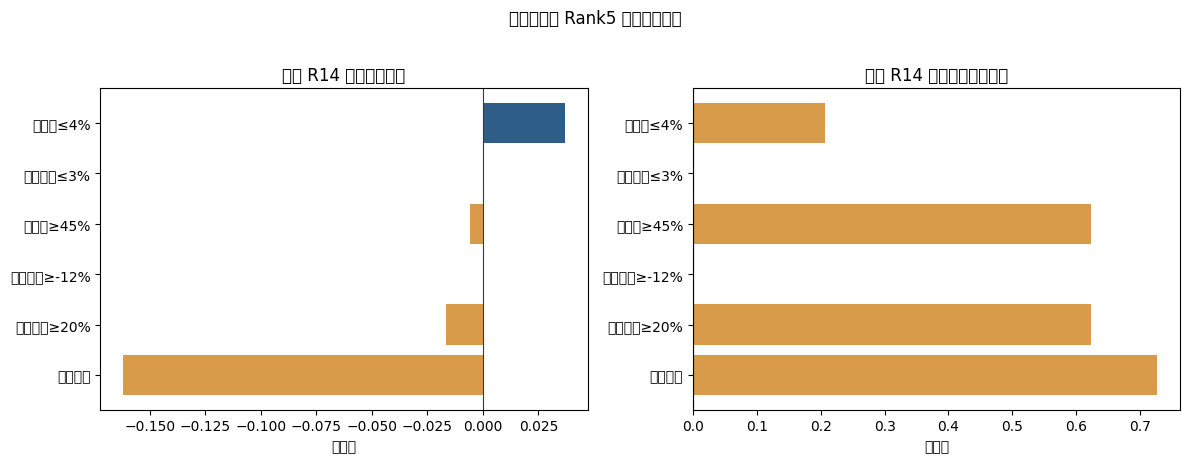

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#2F5D8A" if value >= 0 else "#D89B4A" for value in results["收益差pp"]]
axes[0].barh(results["候选"], results["收益差pp"], color=colors)
axes[0].axvline(0, color="#343A40", linewidth=0.8)
axes[0].set_title("相对 R14 的总收益变化")
axes[0].set_xlabel("百分点")
axes[0].invert_yaxis()
colors = ["#D89B4A" if value > 0 else "#2F5D8A" for value in results["跳过率差pp"]]
axes[1].barh(results["候选"], results["跳过率差pp"], color=colors)
axes[1].axvline(0, color="#343A40", linewidth=0.8)
axes[1].set_title("相对 R14 的跳过订单率变化")
axes[1].set_xlabel("百分点")
axes[1].invert_yaxis()
fig.suptitle("六个预注册 Rank5 路径质量变体", y=1.02)
fig.tight_layout()
plt.show()

最接近的波动率变体只过滤了一笔替补买入，收益改善极小，且以更多跳单为代价。下行波动和路径回撤阈值没有改变任何交易；其余变体减少 5–6 笔替补，但收益与跳过率都没有形成可接受交换。

In [5]:
diagnostics = experiment["baseline_rank5_diagnostics"]
feature_rows = []
feature_labels = {
    "path_realized_volatility_20d": "日波动率",
    "path_downside_semivolatility_20d": "下行半波动",
    "path_max_drawdown_20d": "20日路径回撤",
    "path_up_day_ratio_20d": "上涨日占比",
    "path_trend_efficiency_20d": "趋势效率",
}
for feature, values in diagnostics["feature_outcome_diagnostic"].items():
    feature_rows.append({
        "特征": feature_labels[feature],
        "样本": values["non_null_count"],
        "盈利交易中位数": values["winner_median"],
        "亏损交易中位数": values["loser_median"],
        "全体中位数": values["overall_median"],
    })
pd.DataFrame(feature_rows).round(4)

,特征,样本,盈利交易中位数,亏损交易中位数,全体中位数
0,下行半波动,22,0.0073,0.0101,0.0078
1,20日路径回撤,22,-0.0380,-0.0458,-0.0443
2,日波动率,22,0.0105,0.0290,0.0136
3,趋势效率,22,0.2873,0.4819,0.3531
4,上涨日占比,22,0.4500,0.5750,0.5500


已平仓 Rank5 只有 22 笔，其中 12 笔盈利。亏损交易的波动率和路径回撤中位数确实更差，但趋势效率和上涨日占比反而更高；这种小样本、方向不一致的结构不足以支持继续训练或精调阈值。

## Takeaways

1. 保留 R14，前后端与日刷计划单不增加、不替换策略。
2. 停止 Rank5 的历史路径阈值搜索：现有简单字段与新增路径字段两轮均未形成稳定优势。
3. 下一阶段优先积累前向纸面执行样本，并建立固定观察窗；没有新增独立样本前，不再从同一 22 笔已平仓交易中挖阈值。
4. 若未来有候选通过历史门禁，仍须先让前向纸面执行使用同一 PIT 特征构造器，才具备上线资格。